# BÀI TẬP LỚN SỐ 1: MULTIMODAL CLASSIFICATION
* **Môn học:** Học sâu và ứng dụng trong thị giác máy tính
* **Nhóm:** group6
* **Dataset**: Flickr30k

## Giới thiệu về mô hình CLIP (Contrastive Language-Image Pre-training)

CLIP là mô hình được OpenAI giới thiệu vào năm 2021, đánh dấu bước ngoặt trong việc kết hợp giữa Thị giác máy tính (Computer Vision) và Xử lý ngôn ngữ tự nhiên (NLP). 

Điểm yếu của các mô hình phân loại truyền thống (như ResNet) là chúng bị bó hẹp trong một bộ nhãn cố định (ví dụ: 1000 lớp của ImageNet). Nếu muốn nhận diện một vật thể mới, ta phải thu thập dữ liệu và train lại lớp cuối. CLIP giải quyết vấn đề này bằng cách học từ **400 triệu cặp hình ảnh - văn bản** trên Internet.

### 1. Kiến trúc cốt lõi: Học tương phản (Contrastive Learning)

CLIP không cố gắng dự đoán "đây là con mèo". Thay vào đó, nó học cách **nối kết** giữa một mô tả văn bản và một bức ảnh tương ứng.

* **Cấu trúc gồm hai phần (Two-tower architecture):**
    * **Image Encoder:** Có thể là ResNet hoặc Vision Transformer (ViT), dùng để chuyển hình ảnh thành một vector đặc trưng (embedding).
    * **Text Encoder:** Một mô hình Transformer, dùng để chuyển câu văn thành một vector đặc trưng cùng kích thước với vector ảnh.
* **Cơ chế hoạt động:** Trong một batch gồm $N$ cặp (ảnh, văn bản), CLIP sẽ cực đại hóa độ tương đồng (cosine similarity) của $N$ cặp đúng và cực tiểu hóa độ tương đồng của $N^2 - N$ cặp sai.


---

### 2. Zero-shot Classification

Đây là khả năng "bá đạo" nhất của CLIP: Phân loại hình ảnh mà không cần xem qua bất kỳ ví dụ nào của lớp đó trong quá trình training.

**Quy trình thực hiện:**
1.  **Tạo Prompt:** Thay vì dùng nhãn đơn lẻ như "dog", ta đưa vào một template prompt như: *"A photo of a [label]"*.
2.  **Vector hóa nhãn:** Tất cả các tên lớp (labels) tiềm năng sẽ được đưa qua Text Encoder để tạo ra các vector embedding văn bản.
3.  **So khớp:** Khi có một ảnh mới, ảnh đó được đưa qua Image Encoder. CLIP sẽ tính toán xem vector ảnh này "gần" với vector của nhãn nào nhất trong không gian vector. Nhãn có độ tương đồng cao nhất sẽ là kết quả dự đoán.

> Zero-shot biến bài toán phân loại (Classification) thành bài toán tìm kiếm ngữ nghĩa (Semantic Search).

---

### 3. Few-shot Classification với Linear Probing (Logistic Regression)

Trong trường hợp ta có một ít dữ liệu thực tế (vài ví dụ cho mỗi lớp) và muốn tối ưu hóa độ chính xác hơn nữa cho một domain cụ thể, ta sử dụng phương pháp **Linear Probing**.

**Cách hoạt động:**
* **Đóng băng (Freeze):** Ta giữ nguyên toàn bộ trọng số của CLIP (cả Image và Text Encoder). Chúng ta coi CLIP như một bộ trích xuất đặc trưng (Feature Extractor) cực mạnh.
* **Trích xuất đặc trưng:** Đưa tập dữ liệu nhỏ của ta qua Image Encoder để thu về các vector đặc trưng.
* **Huấn luyện bộ phân loại tuyến tính:** Sử dụng một thuật toán học máy đơn giản, thường là **Logistic Regression**, để học cách phân loại các vector đặc trưng này vào các nhãn mong muốn.

**Tại sao dùng Logistic Regression?**
Vì đặc trưng từ CLIP đã rất tốt và có tính phân tách cao, một mặt phẳng (linear) đơn giản là đủ để phân loại. Việc này cực kỳ nhanh, không đòi hỏi GPU khủng và tránh được hiện tượng Overfitting khi dữ liệu ít.

---

## Giới thiệu bộ dữ liệu Flickr30k

Flickr30k là một bộ dữ liệu tiêu chuẩn trong các bài toán Image Captioning và Multi-modal Retrieval (tìm kiếm đa phương thức).

* **Quy mô:** Bao gồm **31,783 hình ảnh** được thu thập từ trang web Flickr.
* **Đặc điểm nổi bật:** Mỗi hình ảnh không chỉ có một nhãn đơn lẻ, mà đi kèm với **5 câu mô tả (captions)** khác nhau do con người viết. 
    * Việc có 5 câu mô tả giúp mô hình học được nhiều cách diễn đạt khác nhau cho cùng một thực thể thị giác (ví dụ: một người có thể mô tả "con chó đang chạy", người khác lại viết "con thú cưng màu nâu trên thảm cỏ").
* **Tính ứng dụng:** * Kiểm tra khả năng hiểu ngữ cảnh phức tạp của mô hình (không chỉ là vật thể mà còn là hành động, màu sắc, mối quan hệ không gian).
    * Làm benchmark để so sánh độ hiệu quả của CLIP so với các phương pháp truyền thống.

| Thuộc tính | Chi tiết |
| :--- | :--- |
| Số lượng ảnh | 31,783 |
| Số lượng chú thích | ~158,915 (5 captions/ảnh) |
| Định dạng chú thích | Tiếng Anh, mô tả hành động và thực thể |
| Nguồn dữ liệu | [Kaggle - Flickr Image Dataset](https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset) |

---

## Các thông số đánh giá hiệu năng 

Trong các bài toán phân loại hình ảnh sử dụng CLIP (Zero-shot hoặc Linear Probing), chúng ta cần những thước đo phản ánh đúng khả năng tổng quát hóa của mô hình.

### 1. Accuracy (Độ chính xác tổng thể)

Accuracy là chỉ số phổ biến nhất, tính bằng tỉ lệ giữa số lượng mẫu dự đoán đúng trên tổng số mẫu.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

* **Ý nghĩa:** Cho biết khả năng phân loại đúng "nhìn chung" của CLIP trên toàn bộ tập dữ liệu Flickr30k.
* **Điểm yếu:** Accuracy cực kỳ "nguy hiểm" nếu tập dữ liệu của ta bị lệch. 
    * *Ví dụ:* Nếu tập test có 90 ảnh là "người" và 10 ảnh là "chó". Một mô hình "ngu ngơ" luôn dự đoán là "người" vẫn đạt Accuracy 90%, nhưng thực tế nó không hề biết nhận diện "chó". 
    * Trong Flickr30k, các thực thể xuất hiện không đồng đều, nên Accuracy chỉ là điều kiện cần, không phải điều kiện đủ.

### 2. Macro-F1 Score

Để hiểu Macro-F1, trước hết ta cần nắm lại **F1-Score** cho từng lớp (Class-wise F1). F1-Score là trung bình điều hòa giữa Precision (Độ chính xác) và Recall (Độ bao phủ).

**Macro-F1** được tính bằng cách lấy trung bình cộng của F1-Score từ tất cả các lớp:

$$\text{Macro-F1} = \frac{1}{N} \sum_{i=1}^{N} F1_i$$

* **Tại sao lại dùng "Macro"?** Chỉ số này đối xử với mọi lớp có **vai trò ngang nhau**, bất kể lớp đó có nhiều hay ít dữ liệu.
* **Ý nghĩa trong báo cáo:** * Nếu **Accuracy cao** nhưng **Macro-F1 thấp**: Nghĩa là CLIP chỉ đang làm tốt ở các lớp phổ biến và đang "tạch" ở các lớp hiếm (minority classes).
    * Nếu cả hai đều cao: Mô hình của ta thực sự ổn định và nhận diện tốt đa dạng các khái niệm trong ảnh.

| Chỉ số | Đặc điểm chính | Phản ánh điều gì? |
| :--- | :--- | :--- |
| **Accuracy** | Chú tâm vào *số lượng* | Hiệu suất khai thác tổng thể trên tập dữ liệu. |
| **Macro-F1** | Chú tâm vào *sự công bằng* | Khả năng nhận diện các khái niệm hiếm/khó trong Flickr30k. |

> Đối với CLIP Zero-shot, Macro-F1 quan trọng hơn Accuracy. Vì Zero-shot vốn dĩ là để kiểm tra khả năng "hiểu" thế giới một cách tổng quát, nếu nó chỉ đúng ở các lớp dễ mà sai sạch ở các lớp khó, thì sức mạnh thực sự của Contrastive Learning chưa được phát huy.

---


## Chuẩn bị môi trường

In [82]:
%pip install transformers torch scikit-learn pillow tqdm pandas numpy matplotlib seaborn kagglehub 

Note: you may need to restart the kernel to use updated packages.


In [83]:
import os
import pandas as pd
import numpy as np
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

### Tải dữ liệu bằng Kaggle Hub

In [84]:
import kagglehub
import os

# Download the latest version
path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")

# Scan the directory to find the exact path of results.csv
csv_path = ""
image_path = ""
for root, dirs, files in os.walk(path):
    if "results.csv" in files:
        csv_path = os.path.join(root, "results.csv")
        image_path = os.path.join(root, "flickr30k_images/")
        break

print(f"CSV path: {csv_path}\nFolder images path: {image_path}\n")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

CSV path: /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/results.csv
Folder images path: /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/

Using cuda


### Tải mô hình CLIP

In [85]:

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
print("Đã tải xong mô hình CLIP")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đã tải xong mô hình CLIP


## Các bước EDA

### Tải dữ liệu

In [86]:
df = pd.read_csv(csv_path, sep='|')
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [87]:
# Loại bỏ Na
df = df.dropna()

Vì `df.columns` có chứa hai cột có khoảng trắng (`' comment_number', ' comment'`) nên ta cần `strip`

In [88]:
print("Trước: ", df.columns)
df.columns = df.columns.str.strip()
print("Sau: ", df.columns)

Trước:  Index(['image_name', ' comment_number', ' comment'], dtype='str')
Sau:  Index(['image_name', 'comment_number', 'comment'], dtype='str')


### Thống kê tần suất từ vựng (Word Frequency)

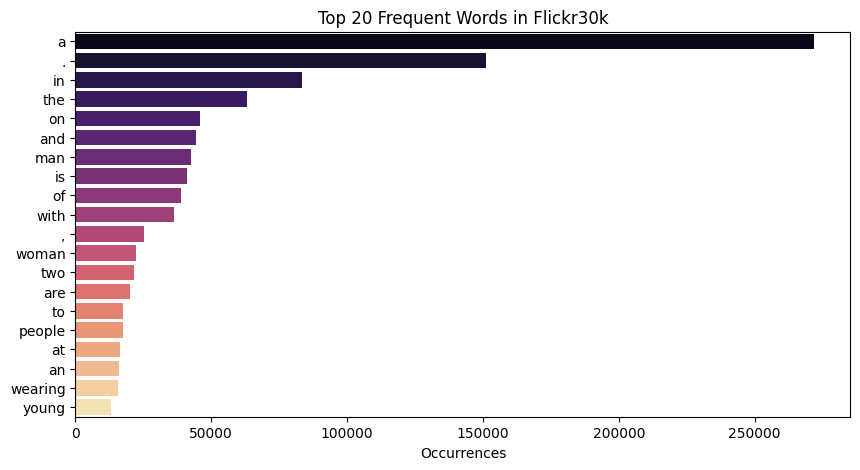

In [89]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten all captions into a single list of lowercase words
all_words = ' '.join(df['comment'].astype(str)).lower().split()
word_counts = Counter(all_words)
words, counts = zip(*word_counts.most_common(20))

# Plot the 20 most frequent words
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 20 Frequent Words in Flickr30k')
plt.xlabel('Occurrences')
plt.show()

### Phân tích độ dài câu

Recommended MAX_SEQ_LEN: 23


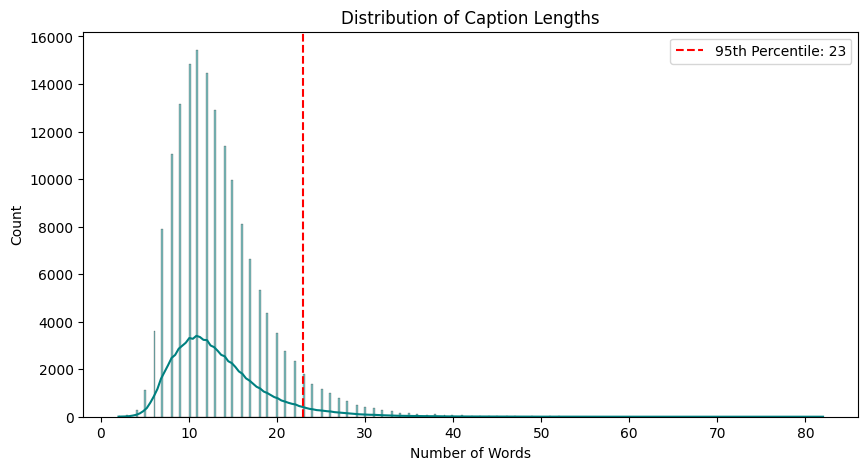

In [90]:
# Calculate word count for each caption entry
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))

# Calculate the 95th percentile for optimal sequence length
p95 = int(df['word_count'].quantile(0.95))
print(f"Recommended MAX_SEQ_LEN: {p95}")

# Plotting the length distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], kde=True, color='teal')
plt.axvline(p95, color='red', linestyle='--', label=f'95th Percentile: {p95}')
plt.title('Distribution of Caption Lengths')
plt.xlabel('Number of Words')
plt.legend()
plt.show()

## Tiền xử lý dữ liệu

In [91]:
import re

def clean_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove punctuation and numbers using regex
    # Only keep alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespaces
    text = " ".join(text.split())
    return text

# Apply the cleaning function to create 'clean_caption' column
df['clean_caption'] = df['comment'].apply(clean_text)

# Check the result before building vocabulary
print(f"Raw: {df['comment'].iloc[0]}")
print(f"Cleaned: {df['clean_caption'].iloc[0]}")
df.head()

Raw:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Cleaned: two young guys with shaggy hair look at their hands while hanging out in the yard


,image_name,comment_number,comment,word_count,clean_caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...,17,two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many...",11,two young white males are outside near many bu...
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .,11,two men in green shirts are standing in a yard
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .,11,a man in a blue shirt standing in a garden
4,1000092795.jpg,4,Two friends enjoy time spent together .,7,two friends enjoy time spent together


In [92]:
df_grouped = df.groupby('image_name')['clean_caption'].first().reset_index()
df_grouped.columns = ['image', 'caption']

print(f"Các cột sau khi làm sạch: {df_grouped.columns.tolist()}")
df_grouped.head()

Các cột sau khi làm sạch: ['image', 'caption']


,image,caption
0,1000092795.jpg,two young guys with shaggy hair look at their ...
1,10002456.jpg,several men in hard hats are operating a giant...
2,1000268201.jpg,a child in a pink dress is climbing up a set o...
3,1000344755.jpg,someone in a blue shirt and hat is standing on...
4,1000366164.jpg,two men one in a gray shirt one in a black shi...


In [93]:
# Lọc ảnh tồn tại
valid_rows = []
for idx, row in df_grouped.iterrows():
    img_path = os.path.join(image_path, row['image'])
    if os.path.exists(img_path):
        valid_rows.append({
            'path': img_path,
            'caption': row['caption'],
            'image_name': row['image']
        })


df_valid = pd.DataFrame(valid_rows)
print(f"Tổng số ảnh hợp lệ: {len(df_valid)}")

Tổng số ảnh hợp lệ: 31783


In [94]:
# Định nghĩa nhãn và regex tương ứng
LABEL_MAP = {
    "man": r"\b(man|men|guy|guys|boy|boys|male)\b",
    "dog": r"\b(dog|dogs|puppy|puppies)\b",
    "car": r"\b(car|cars|vehicle|autos)\b",
    "bike": r"\b(bike|bikes|bicycle|bicycles|motorcycle)\b",
    "woman": r"\b(woman|women|girl|girls|lady|ladies|female)\b",
    "water": r"\b(water|ocean|sea|lake|river|pool|beach|surf|shore)\b",
    "tree": r"\b(tree|trees|forest|woods|grass|field|garden|nature|plant)\b",
    "building": r"\b(building|house|skyscraper|street|sidewalk|city|structure|wall)\b",
    "ball": r"\b(ball|basketball|soccer|football|baseball|tennis|volleyball)\b",
}

TARGET_CLASSES = list(LABEL_MAP.keys())
print(TARGET_CLASSES)

# Pre-compile regex
COMPILED_REGEX = {cls: re.compile(pattern, re.IGNORECASE) for cls, pattern in LABEL_MAP.items()}

def assign_label(caption):
    if not isinstance(caption, str):
        return None
    
    counts = {}
    for cls, pattern in COMPILED_REGEX.items():
        # Tìm tất cả các khớp (matches)
        matches = pattern.findall(caption)
        if matches:
            counts[cls] = len(matches)
    
    if not counts:
        return None
        
    # Trả về class có số lần xuất hiện nhiều nhất
    return max(counts, key=counts.get)

['man', 'dog', 'car', 'bike', 'woman', 'water', 'tree', 'building', 'ball']


In [95]:
# Áp dụng hàm gán nhãn
df_valid['label'] = df_valid['caption'].apply(assign_label)
df_clean = df_valid.dropna(subset=['label']).reset_index(drop=True)

print(f"Số lượng ảnh sau lọc: {len(df_clean)}")
if not df_clean.empty:
    print(df_clean['label'].value_counts())

Số lượng ảnh sau lọc: 26297
label
man         13042
woman        6190
dog          1806
building     1567
water        1096
ball          957
tree          699
bike          574
car           366
Name: count, dtype: int64


### Zero-shot Classification với CLIP

In [96]:
from torch.utils.data import Dataset, DataLoader

# Tạo Dataset và DataLoader cho giai đoạn Zero-shot
class FlickrDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['path']).convert("RGB")
            pixel_values = self.processor(images=image, return_tensors="pt").pixel_values
            return pixel_values.squeeze(0), row['label']
        except Exception:
            return None, None

# Custom collate_fn để bỏ qua các mẫu lỗi
def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None
    pixel_values = torch.stack([item[0] for item in batch])
    labels = [item[1] for item in batch]
    return pixel_values, labels

# Hàm chạy zero-shot benchmark
@torch.no_grad()
def run_zero_shot_bench(df, model, processor, target_classes, templates, batch_size=32):
    device = next(model.parameters()).device
    
    print("Pre-computing text features...")
    text_features_list = []
    for cls in target_classes:
        cls_texts = [tmpl.format(cls) for tmpl in templates]
        inputs = processor(text=cls_texts, return_tensors="pt", padding=True).to(device)
        # Lấy embedding và chuẩn hóa ngay
        embeds = model.get_text_features(**inputs)
        embeds = embeds.pooler_output
        embeds = embeds / (embeds.norm(dim=-1, keepdim=True) + 1e-8)
        # Trung bình cộng các templates của cùng 1 class để tạo 1 vector đại diện duy nhất
        text_features_list.append(embeds.mean(dim=0, keepdim=True))
    
    # Shape: [num_classes, embed_dim]
    final_text_features = torch.cat(text_features_list, dim=0)
    final_text_features /= (final_text_features.norm(dim=-1, keepdim=True) + 1e-8)

    # --- PHASE 2: BATCH INFERENCE ---
    dataset = FlickrDataset(df, processor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, 
                            num_workers=4, collate_fn=collate_fn)

    all_preds = []
    all_trues = []

    for images, labels in tqdm(dataloader, desc="Zero-Shot Batching"):
        if images is None: continue
        
        images = images.to(device)
        # Trích xuất image features
        image_features = model.get_image_features(pixel_values=images)
        image_features = image_features.pooler_output
        image_features = image_features / (image_features.norm(dim=-1, keepdim=True) + 1e-8)

        # Tính Similarity matrix: [batch_size, num_classes]
        # Công thức: S = I \cdot T^T
        logits = image_features @ final_text_features.T
        
        # Lấy index của class cao nhất
        preds_idx = logits.argmax(dim=-1).cpu().numpy()
        
        all_preds.extend([target_classes[i] for i in preds_idx])
        all_trues.extend(labels)

    acc = accuracy_score(all_trues, all_preds)
    f1 = f1_score(all_trues, all_preds, average='macro')
    print(f"\nZero-Shot Accuracy: {acc:.4f}. Macro-F1: {f1}")
    print(classification_report(all_trues, all_preds))
    
    return acc, f1

In [97]:
# Chạy zero-shot benchmark
templates = [
    "a photo of a {}",
    "a picture of a {}",
    "an image of a {}",
    "i see a {}"
]
zero_shot_accuracy, zero_shot_f1_score = run_zero_shot_bench(df_clean, model, processor, TARGET_CLASSES, templates, batch_size=128)

Pre-computing text features...


Zero-Shot Batching:   0%|          | 0/206 [00:00<?, ?it/s]


Zero-Shot Accuracy: 0.6008. Macro-F1: 0.4758332755564848
              precision    recall  f1-score   support

        ball       0.29      0.77      0.42       957
        bike       0.27      0.91      0.42       574
    building       0.36      0.27      0.31      1567
         car       0.24      0.57      0.34       366
         dog       0.75      0.91      0.82      1806
         man       0.85      0.53      0.65     13042
        tree       0.28      0.16      0.20       699
       water       0.36      0.57      0.44      1096
       woman       0.63      0.75      0.69      6190

    accuracy                           0.60     26297
   macro avg       0.45      0.60      0.48     26297
weighted avg       0.69      0.60      0.61     26297



In [106]:
# --- Few-Shot Classification ---
@torch.no_grad()
def get_embeddings(df, model, processor, batch_size=32):
    """Trích xuất embedding theo batch, tối ưu GPU và CPU I/O"""
    device = next(model.parameters()).device
    dataset = FlickrDataset(df, processor)
    dataloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=4, 
        collate_fn=collate_fn
    )

    all_embeddings = []
    all_labels = []

    model.eval()
    for images, labels in tqdm(dataloader, desc="Extracting Embeddings"):
        if images is None: continue
        
        images = images.to(device)
        # Sử dụng API chuẩn của CLIP để lấy image features
        features = model.get_image_features(pixel_values=images)
        features = features.pooler_output
        # Chuẩn hóa ngay trên GPU (L2 Norm)
        features = features / (features.norm(dim=-1, keepdim=True) + 1e-8)
        
        all_embeddings.append(features.cpu().numpy())
        all_labels.extend(labels)

    return np.vstack(all_embeddings), all_labels


print("\nBắt đầu Few-Shot Classification")

SHOTS_PER_CLASS = 64
train_list = []
test_list = []

# 1. Chuẩn bị dữ liệu (Data Splitting)
for cls in TARGET_CLASSES:
    cls_df = df_clean[df_clean['label'] == cls]
    if len(cls_df) < SHOTS_PER_CLASS + 5:
        print(f"Bỏ qua lớp {cls}: Chỉ có {len(cls_df)} mẫu.")
        continue
    
    shuffled = cls_df.sample(frac=1, random_state=42)
    train_list.append(shuffled.iloc[:SHOTS_PER_CLASS])
    test_list.append(shuffled.iloc[SHOTS_PER_CLASS:])

if not train_list:
    raise RuntimeError("Không có đủ dữ liệu cho bất kỳ lớp nào!")

df_train = pd.concat(train_list).reset_index(drop=True)
df_test = pd.concat(test_list).reset_index(drop=True)

# 2. Trích xuất đặc trưng (Batch Processing)
print(f"Đang xử lý Train set ({len(df_train)} ảnh)...")
X_train, y_train = get_embeddings(df_train, model, processor, batch_size=256)

print(f"Đang xử lý Test set ({len(df_test)} ảnh)...")
X_test, y_test = get_embeddings(df_test, model, processor, batch_size=256)


Bắt đầu Few-Shot Classification
Đang xử lý Train set (576 ảnh)...


Extracting Embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Đang xử lý Test set (25721 ảnh)...


Extracting Embeddings:   0%|          | 0/101 [00:00<?, ?it/s]

In [107]:
# 3. Huấn luyện Logistic Regression
print("Đang huấn luyện Linear Classifier...")
clf = LogisticRegression(
    max_iter=1000, 
    solver='lbfgs',
    class_weight='balanced',
    C=1.0
)
clf.fit(X_train, y_train)

Đang huấn luyện Linear Classifier...


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [108]:
# 4. Đánh giá
y_pred = clf.predict(X_test)
fs_accuracy = accuracy_score(y_test, y_pred)
fs_f1_score = f1_score(y_test, y_pred, average='macro')
print(f"\nFew-Shot ({SHOTS_PER_CLASS} shots) Accuracy: {fs_accuracy:.4f}. Macro-F1: {fs_f1_score:.4f}")
print(classification_report(y_test, y_pred))


Few-Shot (64 shots) Accuracy: 0.5436. Macro-F1: 0.4796
              precision    recall  f1-score   support

        ball       0.44      0.82      0.57       893
        bike       0.33      0.78      0.47       510
    building       0.23      0.56      0.32      1503
         car       0.15      0.58      0.24       302
         dog       0.81      0.90      0.85      1742
         man       0.88      0.42      0.57     12978
        tree       0.13      0.39      0.20       635
       water       0.30      0.80      0.44      1032
       woman       0.71      0.60      0.65      6126

    accuracy                           0.54     25721
   macro avg       0.44      0.65      0.48     25721
weighted avg       0.72      0.54      0.58     25721



In [109]:
print("KẾT LUẬN:")
print(f"Zero-Shot Accuracy: {zero_shot_accuracy:.4f} | Macro F1: {zero_shot_f1_score:.4f}")
print(f"Few-Shot Accuracy:  {fs_accuracy:.4f} | Macro F1: {fs_f1_score:.4f}")

if fs_f1_score > zero_shot_f1_score:
    print("=> Few-shot learning đã cải thiện hiệu suất!")
else:
    print("=> Zero-shot vẫn hoạt động tốt hơn hoặc tương đương.")

KẾT LUẬN:
Zero-Shot Accuracy: 0.6008 | Macro F1: 0.4758
Few-Shot Accuracy:  0.5436 | Macro F1: 0.4796
=> Few-shot learning đã cải thiện hiệu suất!


## Phần mở rộng
### Tinh chỉnh Hyperparameters

In [110]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, accuracy_score

print("Bắt đầu tối ưu hóa Hyperparameters...")

# 1. Định nghĩa không gian tham số (Search Space)
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],  # Độ mạnh của Regularization
    'l1_ratio': [0] ,              # penalty was deprecated in version 1.8 and will be removed in 1.10. l1_ratio=0 for penalty='l2', l1_ratio=1 for penalty='l1' and l1_ratio set to any float between 0 and 1 for 'penalty='elasticnet'.
    'class_weight': [None, 'balanced'],   # Xử lý mất cân bằng dữ liệu
    'solver': ['lbfgs', 'saga']          # Saga tốt hơn cho tập dữ liệu lớn/nhiều features
}

# 2. Định nghĩa các hàm chấm điểm
scoring = {
    'Accuracy': 'accuracy',
    'Macro_F1': make_scorer(f1_score, average='macro')
}

# 3. Khởi tạo Grid Search với 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring=scoring,
    refit='Macro_F1', 
    cv=5,
    verbose=1,
    n_jobs=-1 # Chạy song song trên toàn bộ nhân CPU
)

# 4. Thực thi tìm kiếm
grid_search.fit(X_train, y_train)

# 5. Trích xuất kết quả
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBộ tham số tốt nhất (theo Macro-F1): {best_params}")
print(f"Macro-F1 cao nhất trên tập Train (CV): {best_score:.4f}")

# 6. Đánh giá trên tập Test độc lập
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nKẾT QUẢ TRÊN TẬP TEST:")
print(f"- Accuracy: {test_acc:.4f}")
print(f"- Macro-F1: {test_f1:.4f}")

Bắt đầu tối ưu hóa Hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Bộ tham số tốt nhất (theo Macro-F1): {'C': 10.0, 'class_weight': None, 'l1_ratio': 0, 'solver': 'saga'}
Macro-F1 cao nhất trên tập Train (CV): 0.6694

KẾT QUẢ TRÊN TẬP TEST:
- Accuracy: 0.5492
- Macro-F1: 0.4873


In [111]:
best_clf = LogisticRegression(
    max_iter=1000, 
    solver='lbfgs',
    class_weight='balanced',
    l1_ratio=0,
    C=10.0,
)
best_clf.fit(X_train, y_train)
fs_accuracy = accuracy_score(y_test, y_pred)
fs_f1_score = f1_score(y_test, y_pred, average='macro')
print(f"\nFew-Shot ({SHOTS_PER_CLASS} shots) Accuracy: {fs_accuracy:.4f}. Macro-F1: {fs_f1_score:.4f}")
print(classification_report(y_test, y_pred))


Few-Shot (64 shots) Accuracy: 0.5492. Macro-F1: 0.4873
              precision    recall  f1-score   support

        ball       0.49      0.78      0.60       893
        bike       0.36      0.80      0.49       510
    building       0.22      0.52      0.31      1503
         car       0.13      0.60      0.21       302
         dog       0.82      0.88      0.85      1742
         man       0.87      0.44      0.58     12978
        tree       0.15      0.49      0.23       635
       water       0.32      0.78      0.45      1032
       woman       0.72      0.60      0.66      6126

    accuracy                           0.55     25721
   macro avg       0.45      0.65      0.49     25721
weighted avg       0.72      0.55      0.58     25721



In [112]:
print("KẾT LUẬN:")
print(f"Zero-Shot Accuracy: {zero_shot_accuracy:.4f} | Macro F1: {zero_shot_f1_score:.4f}")
print(f"Few-Shot Accuracy:  {fs_accuracy:.4f} | Macro F1: {fs_f1_score:.4f}")

if fs_f1_score > zero_shot_f1_score:
    print("=> Few-shot learning đã cải thiện hiệu suất!")
else:
    print("=> Zero-shot vẫn hoạt động tốt hơn hoặc tương đương.")

KẾT LUẬN:
Zero-Shot Accuracy: 0.6008 | Macro F1: 0.4758
Few-Shot Accuracy:  0.5492 | Macro F1: 0.4873
=> Few-shot learning đã cải thiện hiệu suất!


### Phân tích lỗi 

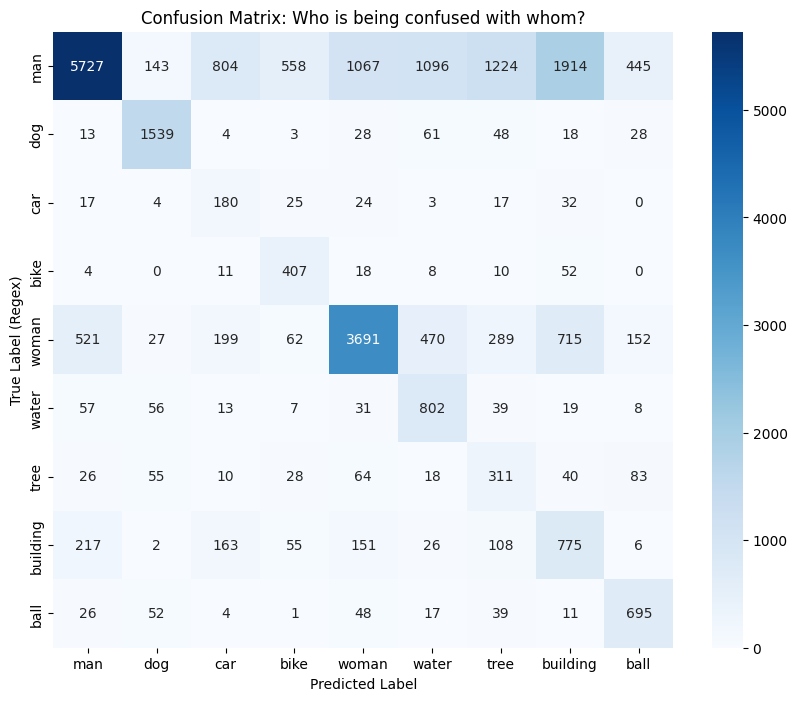


Tổng số mẫu sai: 11594 / 25721

--- TOP 10 HIGH-CONFIDENCE ERRORS (Model rất tự tin nhưng sai so với nhãn Regex) ---
                                                                                                                              path                                                                                                                                                             caption label pred_label  confidence
133    /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/3221128704.jpg                                                                    a man in a purple jersey is falling down while chasing a player in a green jersey playing soccer   man       ball    0.993514
5383   /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/7278633600.jpg                                                                                      a boy playing socc

In [114]:
from sklearn.metrics import confusion_matrix

def perform_error_analysis(X_test, y_test, y_pred, clf, target_classes, df_test):
    # --- 1. CONFUSION MATRIX ---
    cm = confusion_matrix(y_test, y_pred, labels=target_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label (Regex)')
    plt.title('Confusion Matrix: Who is being confused with whom?')
    plt.show()

    # --- 2. TRÍCH XUẤT CÁC MẪU DỰ ĐOÁN SAI (MISCLASSIFIED) ---
    # Tính xác suất (confidence) cho từng dự đoán
    y_probs = clf.predict_proba(X_test)
    
    analysis_df = df_test.copy()
    analysis_df['pred_label'] = y_pred
    # Lấy xác suất của lớp được dự đoán
    analysis_df['confidence'] = [max(prob) for prob in y_probs]
    
    # Lọc ra các dòng sai
    errors = analysis_df[analysis_df['label'] != analysis_df['pred_label']].copy()
    # Sắp xếp theo độ tự tin giảm dần
    errors = errors.sort_values(by='confidence', ascending=False)

    print(f"\nTổng số mẫu sai: {len(errors)} / {len(df_test)}")
    print("\n--- TOP 10 HIGH-CONFIDENCE ERRORS (Model rất tự tin nhưng sai so với nhãn Regex) ---")
    # Hiển thị các cột quan trọng để kiểm tra thủ công
    display_cols = ['path', 'caption', 'label', 'pred_label', 'confidence']
    print(errors[display_cols].head(10).to_string())

    return errors

error_df = perform_error_analysis(X_test, y_test, y_pred, best_clf, TARGET_CLASSES, df_test)


#### 1. Phân tích định lượng tổng thể
Dựa trên kết quả thực nghiệm với mô hình Logistic Regression ($C=10.0$, weighted), ta ghi nhận các chỉ số hiệu năng như sau:
* **Accuracy:** $0.5492$
* **Macro-F1:** $0.4873$
* **Tỷ lệ mẫu sai:** $45.1\%$ ($11.594 / 25.721$)

**Nhận định:** Khoảng cách lớn giữa Accuracy và Macro-F1 cho thấy sự mất cân bằng nghiêm trọng về hiệu suất giữa các lớp. Đặc biệt, lớp `man` có **Precision rất cao (0.87)** nhưng **Recall cực thấp (0.44)**. Điều này chứng tỏ mô hình đang bỏ sót hơn một nửa số đối tượng "người" và gán nhãn chúng sang các thực thể bối cảnh hoặc vật thể trung tâm.

#### 2. Phân tích cấu trúc sai số (Confusion Matrix)
Ma trận nhầm lẫn cho thấy sự dịch chuyển nhãn từ các thực thể chủ thể sang thực thể môi trường:
* **Sự áp đảo của nhiễu bối cảnh:** Có tới $1.914$ mẫu `man` bị nhầm thành `building`, $1.224$ mẫu thành `tree` và $1.096$ mẫu thành `water`. 
* **Đặc tính của lớp "Dog":** Đây là lớp hoạt động hiệu quả nhất ($F1=0.85$). Điều này cho thấy đặc trưng thị giác của loài chó trong không gian CLIP rất tách biệt và ít bị pha trộn với các thực thể khác.
* **Vấn đề của các lớp vật thể nhỏ (`car`, `bike`):** Mặc dù Recall cao ($>0.60$), nhưng Precision lại cực thấp ($0.13$ - $0.36$). Ta kết luận mô hình đang có xu hướng "đoán bừa" vào các lớp này khi gặp những đặc trưng hình học không rõ ràng.

#### 3. Phân tích định tính các mẫu sai số có độ tự tin cực cao (High-Confidence Analysis)
Điểm đáng báo động nhất nằm ở danh sách 10 mẫu sai có **độ tự tin gần như tuyệt đối ($>0.97$)**. Phân tích sâu cho thấy:

* **Tính ưu tiên về độ nổi bật thị giác:** Trong các mẫu liên quan đến bóng đá/bóng rổ (ID `133`, `5383`, `3044`, `3826`), dù chủ thể người xuất hiện dày đặc, mô hình vẫn khẳng định chắc chắn nhãn là `ball` với xác suất $>98\%$. 
    * *Kết luận:* CLIP ưu tiên các vật thể có tương tác động (action-center) hơn là các thực thể tĩnh hoặc thực thể người mang tính bao quát.
* **Lỗi hệ thống từ nhãn Regex (Ground Truth Noise):** Các mẫu về môi trường nước (ID `10404`, `9457`, `12787`, `12436`) cho thấy Regex bắt nhãn `man` dựa trên chủ ngữ, nhưng CLIP nhận diện nhãn là `water`. 

*Kết luận:* Trong các bức ảnh phong cảnh rộng, thực thể bối cảnh chiếm diện tích pixel lớn hơn, dẫn đến vector embedding bị kéo về phía các nhãn môi trường. Nhãn Regex trong trường hợp này đã thất bại trong việc xác định "trọng tâm thị giác" của bức ảnh.

#### 4. Nguyên nhân gốc rễ
Ta xác định ba nguyên nhân chính ngăn cản mô hình đạt ngưỡng hiệu năng cao hơn:
1.  **Sự mâu thuẫn giữa Ngữ pháp và Thị giác:** Nhãn Regex dựa trên cấu trúc câu (thường ưu tiên chủ ngữ là người), trong khi mô hình thị giác dựa trên đặc trưng điểm ảnh và sự nổi bật (salience). Sự lệch pha này khiến hàm loss bị nhiễu nặng trong quá trình huấn luyện.
2.  **Regularization yếu ($C=10.0$):** Việc sử dụng hệ số $C$ lớn trong bối cảnh dữ liệu có nhiều nhiễu nhãn đã khiến mô hình quá tự tin (Overconfidence) vào các dự đoán sai. Độ tự tin $0.99$ cho một mẫu sai là minh chứng điển hình của việc mô hình bị "overfit" vào các đặc trưng nhiễu.
3.  **Vấn đề Single-label trong thế giới Multi-object:** Flickr30k vốn dĩ là tập dữ liệu đa thực thể. Việc cưỡng ép phân loại đơn nhãn đang triệt tiêu khả năng học hiểu bối cảnh của CLIP.

#### 5. Hướng tối ưu kết quả
Để tối ưu hóa kết quả, ta cần thực hiện các hành động sau:
* **Hiệu chỉnh dữ liệu bằng CLIP-Consensus:** Loại bỏ toàn bộ các mẫu có sự sai khác giữa dự đoán của CLIP và nhãn Regex khi độ tự tin của CLIP $>0.8$. Đây là những mẫu "nhiễu độc hại".
* **Giảm hệ số C:** Điều chỉnh $C$ về mức $0.1$ hoặc $0.01$ để làm mượt (smooth) ranh giới quyết định, giảm bớt sự tự tin thái quá vào các nhãn nhiễu.
* **Sử dụng Thresholding:** Thay vì lấy `argmax`, ta nên áp dụng một ngưỡng xác suất. Nếu không có nhãn nào vượt qua ngưỡng, mẫu đó nên được phân loại là "Unknown" để đảm bảo tính tinh khiết của tập dữ liệu.
